# Multi-Threshold EMG Trial Initiation Simulator

Runs repeated simulations across a sweep of initiation threshold window sizes.
Produces a curve of **window size (uV)** vs **number of trials**.

In [1]:
# Cell 1: Imports and constants
import numpy as np
import matplotlib.pyplot as plt
from open_ephys.analysis import Session

from helpers import (
    scan_experiment_structure,
    process_emg_signal,
    run_trial_initiation_simulation,
    PROTOCOL_ONLINE,
    SAMPLE_RATE_HINT,
    BIN_DURATION_MS,
)

DEFAULT_PROTOCOL = PROTOCOL_ONLINE
print('Imports loaded. Default protocol:', DEFAULT_PROTOCOL)

Imports loaded. Default protocol: Online Filtering


## 1. Load Session and Recording

In [2]:
# Cell 2: Session directory and record node
directory = "HR-08-Hour_Test_2026-03-26_08-16-26_001"

record_node_name  = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0               if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1

session   = Session(directory)
structure = scan_experiment_structure(directory, record_node_name)

flat_recordings = [
    (exp, rec)
    for exp, rec_list in structure.items()
    for rec in rec_list
]
print(f"Found {len(flat_recordings)} recording(s) across {len(structure)} experiment(s):")
for i, (e, r) in enumerate(flat_recordings):
    print(f"  [{i}] {e}/{r}")

Found 1 recording(s) across 1 experiment(s):
  [0] experiment1/recording1


In [4]:
# Cell 3: Load a specific recording (change RECORDING_INDEX to select another)
import os
RECORDING_INDEX = 0

recording = session.recordnodes[record_node_index].recordings[RECORDING_INDEX]

# Derive experiment/recording names from the recording directory path
parts         = recording.directory.split(os.sep)
recording_name   = parts[-1]
experiment_name  = parts[-2]
directory_str    = directory

# Load continuous stream
stream      = recording.continuous[0]
metadata    = stream.metadata
sample_rate = metadata.sample_rate
timestamps  = stream.timestamps
n_samples   = timestamps.shape[0]
data        = stream.get_samples(start_sample_index=0, end_sample_index=n_samples)

print(f"Loaded: {experiment_name}/{recording_name}")
print(f"Samples: {n_samples:,} | Duration: {timestamps[-1] - timestamps[0]:.1f} s | Rate: {sample_rate} Hz")
print(f"Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

Loaded: experiment1/recording1
Samples: 13,789,220 | Duration: 2760.3 s | Rate: 5000.0 Hz
Channels: 5 | Names: ['CH1', 'CH5', 'CH7', 'CH8', 'ADC1']


## 2. Process EMG Signal

Using Online Filtering: assuming channel 3 is prefiltered differential EMG


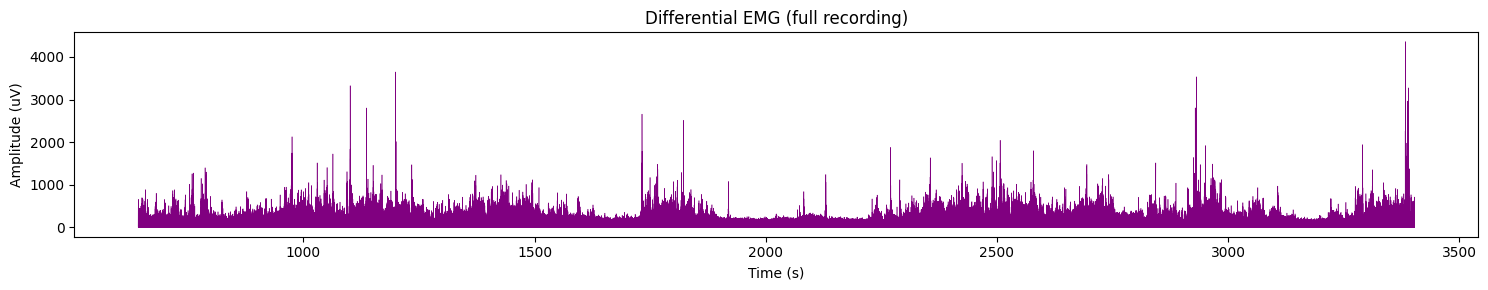

EMG processing complete.


In [5]:
# Cell 4: Compute differential filtered EMG
differential_filt, differential_emg = process_emg_signal(data, record_node_name, sample_rate)

plt.figure(figsize=(15, 3))
plt.plot(timestamps, differential_emg, color='purple', linewidth=0.4)
plt.title('Differential EMG (full recording)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.tight_layout()
plt.show()
print('EMG processing complete.')

## 3. Background EMG Distribution

Use this histogram to choose a sensible centre and range for the threshold sweep.

In [ ]:
# Cell 5: Background distribution -- derive centre statistics
_bin_size  = int((sample_rate / 1000) * BIN_DURATION_MS)
_n_bins    = len(differential_emg) // _bin_size
_trimmed   = differential_emg[:_n_bins * _bin_size]
_bin_means = np.abs(_trimmed.reshape(_n_bins, _bin_size)).mean(axis=1)

_q25, _q50, _q75 = np.percentile(_bin_means, [25, 50, 75])
_std = _bin_means.std()
_iqr = _q75 - _q25

print(f'Bin mean distribution:  median={_q50:.2f} uV  std={_std:.2f} uV  IQR={_iqr:.2f} uV')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_bin_means, bins=100, color='steelblue', alpha=0.7)
ax.axvline(_q50, color='purple', linestyle='--', label=f'Median {_q50:.1f} uV')
ax.axvline(_q25, color='orange', linestyle=':',  label=f'Q25 {_q25:.1f} uV')
ax.axvline(_q75, color='orange', linestyle=':',  label=f'Q75 {_q75:.1f} uV')
ax.set_xlabel('Bin mean amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title('Background EMG distribution (bin means)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Multi-Simulation Configuration

Define the threshold sweep here.

**Option A** -- provide explicit `(min_uV, max_uV)` pairs in `THRESHOLD_PAIRS`.  
**Option B** -- set `USE_AUTO_SWEEP = True` and specify a centre value plus a list of
half-widths; pairs are built automatically as `(centre - hw, centre + hw)`.

Only one option is active at a time (controlled by `USE_AUTO_SWEEP`).

In [ ]:
# Cell 6: Threshold sweep configuration -- EDIT THIS CELL

# -- Option A: explicit (min_uV, max_uV) pairs --------------------------------
# Each tuple is one simulation run.  Only used when USE_AUTO_SWEEP = False.
THRESHOLD_PAIRS = [
    (20, 30),
    (15, 35),
    (10, 40),
    ( 5, 45),
    ( 0, 50),
]

# -- Option B: automatic sweep around a centre --------------------------------
USE_AUTO_SWEEP    = True               # set False to use THRESHOLD_PAIRS above
SWEEP_CENTRE      = _q50               # centre of the window (uV)
SWEEP_HALF_WIDTHS = np.linspace(1, _std * 2, 20)  # half-widths to sweep

# -- Shared simulation parameters ---------------------------------------------
VERBOSE_SIMS = False   # set True to print per-simulation progress

# -----------------------------------------------------------------------------
# Build the final list of (min_uV, max_uV) pairs
if USE_AUTO_SWEEP:
    THRESHOLD_PAIRS = [
        (float(SWEEP_CENTRE - hw), float(SWEEP_CENTRE + hw))
        for hw in SWEEP_HALF_WIDTHS
    ]

print(f'Number of simulations to run: {len(THRESHOLD_PAIRS)}')
print(f'Window sizes (uV): {[round(mx - mn, 2) for mn, mx in THRESHOLD_PAIRS]}')

## 5. Run All Simulations

In [ ]:
# Cell 7: Run the threshold sweep
results = []  # list of dicts: {min_uv, max_uv, window_size, n_trials, n_successful, stats}

for i, (min_uv, max_uv) in enumerate(THRESHOLD_PAIRS):
    window_size = max_uv - min_uv
    print(
        f'[{i+1:>3}/{len(THRESHOLD_PAIRS)}]  '
        f'min={min_uv:.2f}  max={max_uv:.2f}  window={window_size:.2f} uV  ... ',
        end='', flush=True
    )

    trials, stats_dict = run_trial_initiation_simulation(
        emg_signal=differential_emg,
        timestamps=timestamps,
        sample_rate=sample_rate,
        min_init_threshold=min_uv,
        max_init_threshold=max_uv,
        verbose=VERBOSE_SIMS,
    )

    n_successful = sum(1 for t in trials if t.successful)
    n_total      = len(trials)

    results.append({
        'min_uv':       min_uv,
        'max_uv':       max_uv,
        'window_size':  window_size,
        'n_trials':     n_total,
        'n_successful': n_successful,
        'stats':        stats_dict,
    })

    print(f'{n_total} trials  ({n_successful} successful)')

print('\nAll simulations complete.')

## 6. Plot: Initiation Window Size vs Number of Trials

In [ ]:
# Cell 8: Window-size vs trial-count curve
window_sizes = [r['window_size']  for r in results]
n_trials     = [r['n_trials']     for r in results]
n_successful = [r['n_successful'] for r in results]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(window_sizes, n_trials,     'o-',  color='steelblue', linewidth=2,
        markersize=6, label='Total trials')
ax.plot(window_sizes, n_successful, 's--', color='seagreen',  linewidth=2,
        markersize=6, label='Successful trials')

ax.set_xlabel('Initiation window size (max - min threshold, uV)', fontsize=12)
ax.set_ylabel('Number of trials', fontsize=12)
ax.set_title(
    f'EMG Trial Initiation: Window Size vs Trial Count\nRecording: {directory_str}',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Summary table
header = (
    f"{'Window (uV)':>14}  {'Min (uV)':>10}  {'Max (uV)':>10}  "
    f"{'Total trials':>14}  {'Successful':>12}"
)
print(header)
print('-' * len(header))
for r in results:
    print(
        f"{r['window_size']:>14.2f}  {r['min_uv']:>10.2f}  {r['max_uv']:>10.2f}  "
        f"{r['n_trials']:>14d}  {r['n_successful']:>12d}"
    )